# Module 8 Examples

In [4]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

---

## Ball Falling Minima

This example visualizes gradient descent with momentum by simulating two balls rolling down a curve with both a local and global minimum. Each ball starts at a different position on the function f(x) = 0.5x⁴ − 2x³ + x² + 3x + 1 and follows the negative gradient, with friction dampening its velocity over time. The red ball gets trapped in the local minimum, while the blue ball carries enough momentum to reach the global minimum — illustrating how a starting position and trajectory can determine which solution an optimizer converges to.

**Drop the resulting gif in a browser** such as Google Chrome to see the animation. 

In [ ]:

# Create a function with local and global minima
def f(x):
    return 0.5 * x**4 - 2 * x**3 + x**2 + 3 * x + 1

# Gradient of the function
def df(x):
    return 2 * x**3 - 6 * x**2 + 2 * x + 3

# Create x values
x = np.linspace(-1, 4, 500)
y = f(x)

# Find approximate local and global minima
local_min_x = 0.5  # Approximate local minimum
global_min_x = 3.0  # Approximate global minimum

# Simulate two balls falling (gradient descent with momentum)
class Ball:
    def __init__(self, start_x, color, label):
        self.x = start_x
        self.velocity = 0
        self.color = color
        self.label = label
        self.trajectory = [start_x]
        
    def update(self, learning_rate=0.01, friction=0.85):
        gradient = df(self.x)
        self.velocity = friction * self.velocity - learning_rate * gradient
        self.x += self.velocity
        self.trajectory.append(self.x)

# Initialize balls
ball1 = Ball(start_x=0.3, color='red', label='Ball 1 (Local Min)')
ball2 = Ball(start_x=1.5, color='blue', label='Ball 2 (Global Min)')

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

def animate(frame):
    ax.clear()
    
    # Plot function
    ax.plot(x, y, 'k-', linewidth=2, label='f(x)')
    
    # Update balls
    if frame < 100:  # Run for 100 frames
        ball1.update()
        ball2.update()
    
    # Plot balls
    ax.plot(ball1.x, f(ball1.x), 'o', color=ball1.color, 
            markersize=15, label=ball1.label, zorder=5)
    ax.plot(ball2.x, f(ball2.x), 'o', color=ball2.color, 
            markersize=15, label=ball2.label, zorder=5)
    
    # Plot trajectories
    if len(ball1.trajectory) > 1:
        traj1_x = ball1.trajectory
        traj1_y = [f(xi) for xi in traj1_x]
        ax.plot(traj1_x, traj1_y, color=ball1.color, 
                alpha=0.3, linewidth=1)
    
    if len(ball2.trajectory) > 1:
        traj2_x = ball2.trajectory
        traj2_y = [f(xi) for xi in traj2_x]
        ax.plot(traj2_x, traj2_y, color=ball2.color, 
                alpha=0.3, linewidth=1)
    
    # Mark minima
    ax.axvline(local_min_x, color='red', linestyle='--', 
               alpha=0.3, label='Local Minimum')
    ax.axvline(global_min_x, color='blue', linestyle='--', 
               alpha=0.3, label='Global Minimum')
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.set_title('Ball Falling: Local vs Global Minimum', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1, 4)
    ax.set_ylim(min(y) - 1, max(y) + 1)

# Create animation
anim = FuncAnimation(fig, animate, frames=120, interval=50, repeat=True)

# Save as GIF
writer = PillowWriter(fps=20)
anim.save('ball_falling_minima.gif', writer=writer)
print("✓ Saved: ball_falling_minima.gif")

plt.close()

✓ Saved: ball_falling_minima.gif


---

## Convex Concave Comparisons
The animation below contrasts a **convex function** (f(x) = x²) with a **concave function** (f(x) = −x²) by sweeping a tangent line across each curve. For the convex case, the curve always lies *above* its tangent — the defining geometric property that guarantees gradient descent converges to a global minimum. For the concave case, the curve lies *below* its tangent, meaning any local descent leads away from rather than toward an optimum. The shaded region highlights this above/below relationship at each point, making it easy to see why convexity is such a valuable property in optimization.
**Drop the resulting gif in a browser** such as Google Chrome to see the animation.

In [6]:
# Define convex and concave functions
def convex_func(x):
    return x**2

def concave_func(x):
    return -x**2

# Create x values
x = np.linspace(-3, 3, 500)
y_convex = convex_func(x)
y_concave = concave_func(x)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def animate(frame):
    ax1.clear()
    ax2.clear()
    
    # Animation parameters
    t = frame / 30.0  # Slow down animation
    x_point = -3 + (t % 6)  # Move point from -3 to 3 and repeat
    
    # CONVEX FUNCTION (left plot)
    ax1.plot(x, y_convex, 'b-', linewidth=2.5, label='Convex: f(x) = x²')
    
    # Show tangent line for convex
    if -2.5 <= x_point <= 2.5:
        slope_convex = 2 * x_point  # Derivative of x^2
        tangent_convex = slope_convex * (x - x_point) + convex_func(x_point)
        ax1.plot(x, tangent_convex, 'r--', linewidth=1.5, alpha=0.7, label='Tangent line')
        ax1.plot(x_point, convex_func(x_point), 'ro', markersize=10, zorder=5)
        
        # Show that function lies above tangent (convex property)
        mask = (x >= x_point - 1.5) & (x <= x_point + 1.5)
        ax1.fill_between(x[mask], tangent_convex[mask], y_convex[mask], 
                         where=(y_convex[mask] >= tangent_convex[mask]),
                         alpha=0.2, color='green', label='Function above tangent')
    
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('f(x)', fontsize=12)
    ax1.set_title('Convex Function (∪ shape)\n"Holds water"', 
                  fontsize=13, fontweight='bold', color='blue')
    ax1.grid(True, alpha=0.3)
    #ax1.legend(loc='upper center', fontsize=9)
    ax1.set_ylim(-1, 10)
    ax1.set_xlim(-3, 3)
    ax1.axhline(y=0, color='k', linewidth=0.5)
    ax1.axvline(x=0, color='k', linewidth=0.5)
    
    # Add text annotation
    ax1.text(0, 8.5, 'f"(x) > 0 everywhere\n(curves upward)', 
             ha='center', fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # CONCAVE FUNCTION (right plot)
    ax2.plot(x, y_concave, 'r-', linewidth=2.5, label='Concave: f(x) = -x²')
    
    # Show tangent line for concave
    if -2.5 <= x_point <= 2.5:
        slope_concave = -2 * x_point  # Derivative of -x^2
        tangent_concave = slope_concave * (x - x_point) + concave_func(x_point)
        ax2.plot(x, tangent_concave, 'b--', linewidth=1.5, alpha=0.7, label='Tangent line')
        ax2.plot(x_point, concave_func(x_point), 'bo', markersize=10, zorder=5)
        
        # Show that function lies below tangent (concave property)
        mask = (x >= x_point - 1.5) & (x <= x_point + 1.5)
        ax2.fill_between(x[mask], y_concave[mask], tangent_concave[mask],
                         where=(y_concave[mask] <= tangent_concave[mask]),
                         alpha=0.2, color='orange', label='Function below tangent')
    
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('f(x)', fontsize=12)
    ax2.set_title('Concave Function (∩ shape)\n"Spills water"', 
                  fontsize=13, fontweight='bold', color='red')
    ax2.grid(True, alpha=0.3)
    #ax2.legend(loc='lower center', fontsize=9)
    ax2.set_ylim(-10, 1)
    ax2.set_xlim(-3, 3)
    ax2.axhline(y=0, color='k', linewidth=0.5)
    ax2.axvline(x=0, color='k', linewidth=0.5)
    
    # Add text annotation
    ax2.text(0, -8.5, 'f"(x) < 0 everywhere\n(curves downward)', 
             ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()

# Create animation
anim = FuncAnimation(fig, animate, frames=180, interval=50, repeat=True)

# Save as GIF
writer = PillowWriter(fps=20)
anim.save('convex_vs_concave.gif', writer=writer)
print("✓ Saved: convex_vs_concave.gif")

plt.close()

✓ Saved: convex_vs_concave.gif


---

## Gradient Descent
This example animates three gradient descent optimizers — vanilla GD, Momentum, and Adam — descending
a simple elliptical cost surface defined by $J(\theta) = \frac{1}{2}(\theta_1^2 + 5\theta_2^2)$. The
elongated bowl shape (with curvature ratio 5:1) is a classic stress test for optimizers: steep in one
direction, shallow in the other. All three start from the same point $(2.5, 2.5)$ and run for 25 steps.
The contour plot traces each path, while animated markers show the live position at each iteration —
making it easy to compare convergence speed and trajectory smoothness across methods.

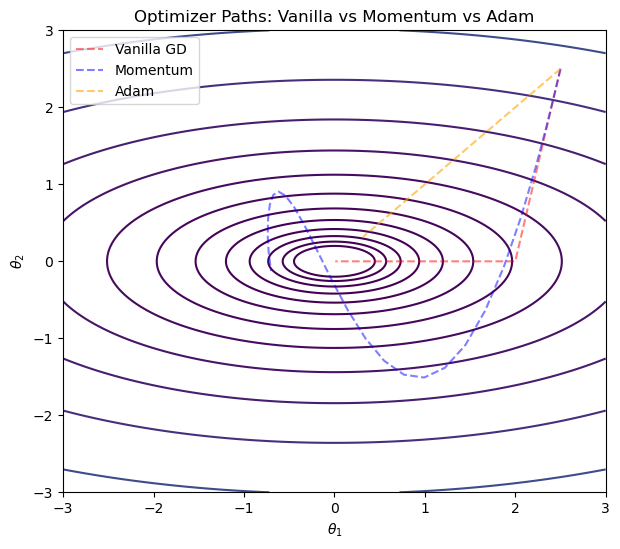

In [8]:
# Define cost and gradient
def cost(theta):
    a, b = 1.0, 5.0
    return 0.5 * (a * theta[0]**2 + b * theta[1]**2)

def grad(theta):
    a, b = 1.0, 5.0
    return np.array([a * theta[0], b * theta[1]])

# Generate contour grid
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (X**2 + 5 * Y**2)

# ---- Vanilla GD Path ----
eta = 0.2
theta = np.array([2.5, 2.5])
path_v = [theta.copy()]
for _ in range(25):
    g = grad(theta)
    theta = theta - eta * g
    path_v.append(theta.copy())
path_v = np.array(path_v)

# ---- Momentum Path ----
eta, beta = 0.2, 0.9
theta = np.array([2.5, 2.5])
v = np.zeros_like(theta)
path_m = [theta.copy()]
for _ in range(25):
    g = grad(theta)
    v = beta * v + (1 - beta) * g
    theta = theta - eta * v
    path_m.append(theta.copy())
path_m = np.array(path_m)

# ---- Adam Path ----
eta, beta1, beta2, eps = 0.1, 0.9, 0.999, 1e-8
theta = np.array([2.5, 2.5])
m = np.zeros_like(theta)
v = np.zeros_like(theta)
path_a = [theta.copy()]
for t in range(1, 26):
    g = grad(theta)
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * (g ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    theta = theta - eta * m_hat / (np.sqrt(v_hat) + eps)
    path_a.append(theta.copy())
path_a = np.array(path_a)

# ---- Create Figure ----
fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, Z, levels=np.logspace(-1, 2, 15), cmap='viridis')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title("Optimizer Paths: Vanilla vs Momentum vs Adam")

# Plot static trajectories
ax.plot(path_v[:,0], path_v[:,1], 'r--', alpha=0.5, label='Vanilla GD')
ax.plot(path_m[:,0], path_m[:,1], 'b--', alpha=0.5, label='Momentum')
ax.plot(path_a[:,0], path_a[:,1], 'orange', linestyle='--', alpha=0.6, label='Adam')

# Add moving "balls"
ball_v, = ax.plot([], [], 'ro', markersize=10)
ball_m, = ax.plot([], [], 'bo', markersize=10)
ball_a, = ax.plot([], [], 'o', color='orange', markersize=10)
ax.legend()

# ---- Animation Function ----
def init():
    ball_v.set_data([], [])
    ball_m.set_data([], [])
    ball_a.set_data([], [])
    return ball_v, ball_m, ball_a

def update(frame):
    ball_v.set_data([path_v[frame,0]], [path_v[frame,1]])
    ball_m.set_data([path_m[frame,0]], [path_m[frame,1]])
    ball_a.set_data([path_a[frame,0]], [path_a[frame,1]])
    return ball_v, ball_m, ball_a

anim = FuncAnimation(
    fig, update, frames=len(path_v),
    init_func=init, blit=True, interval=150, repeat=True
)

plt.show()

# ---- To save as a GIF ----
anim.save("optimizer_paths.gif", writer="pillow", fps=10)

---

## Gradient Descent examples:
### Gradient Descent for Linear Regression

In [15]:
# Dataset: (x, y)
X = np.array([1, 2, 3], dtype=float)
y = np.array([1, 2, 2.5], dtype=float)
m = len(y)

# Add bias term (column of 1s)
X_b = np.c_[np.ones(m), X]   # shape (3, 2)

# Initialize parameters
theta = np.zeros(2)          # [theta_0, theta_1]
eta = 0.1                    # learning rate
iterations = 10

def compute_cost(X_b, y, theta):
    """Mean Squared Error cost function."""
    errors = X_b.dot(theta) - y
    return (1 / (2 * m)) * np.sum(errors ** 2)

def compute_gradient(X_b, y, theta):
    """Compute gradient of J(theta)."""
    errors = X_b.dot(theta) - y
    grad = (1 / m) * X_b.T.dot(errors)
    return grad

print("Initial θ:", theta)
print("Initial Cost:", compute_cost(X_b, y, theta))
print("=" * 40)

# Gradient Descent Iterations
for t in range(iterations):
    grad = compute_gradient(X_b, y, theta)
    theta -= eta * grad

    cost = compute_cost(X_b, y, theta)
    print(f"Iter {t+1:02d}: θ0 = {theta[0]:.4f}, θ1 = {theta[1]:.4f}, J(θ) = {cost:.4f}")

print("=" * 40)
print("Final θ:", theta)


Initial θ: [0. 0.]
Initial Cost: 1.875
Iter 01: θ0 = 0.1833, θ1 = 0.4167, J(θ) = 0.3775
Iter 02: θ0 = 0.2650, θ1 = 0.6022, J(θ) = 0.0804
Iter 03: θ0 = 0.3014, θ1 = 0.6849, J(θ) = 0.0215
Iter 04: θ0 = 0.3176, θ1 = 0.7216, J(θ) = 0.0098
Iter 05: θ0 = 0.3249, θ1 = 0.7380, J(θ) = 0.0075
Iter 06: θ0 = 0.3281, θ1 = 0.7453, J(θ) = 0.0071
Iter 07: θ0 = 0.3296, θ1 = 0.7485, J(θ) = 0.0070
Iter 08: θ0 = 0.3302, θ1 = 0.7500, J(θ) = 0.0069
Iter 09: θ0 = 0.3305, θ1 = 0.7506, J(θ) = 0.0069
Iter 10: θ0 = 0.3307, θ1 = 0.7509, J(θ) = 0.0069
Final θ: [0.3307 0.7509]


---
### Gradient Descent for Logistic Regression

In [16]:
# Dataset: binary classification
# Simple example: predict y given x
X = np.array([1, 2, 3, 4], dtype=float)
y = np.array([0, 0, 1, 1], dtype=float)  # binary targets
m = len(y)

# Add bias term (column of 1s)
X_b = np.c_[np.ones(m), X]   # shape (m, 2)

# Initialize parameters
theta = np.zeros(2)          # [theta_0, theta_1]
eta = 0.1                    # learning rate
iterations = 100

def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def compute_cost(X_b, y, theta):
    """Binary Cross-Entropy (Log Loss)."""
    z = X_b.dot(theta)
    h = sigmoid(z)
    epsilon = 1e-8  # to avoid log(0)
    cost = (-1 / m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

def compute_gradient(X_b, y, theta):
    """Compute gradient of the logistic cost function."""
    z = X_b.dot(theta)
    h = sigmoid(z)
    grad = (1 / m) * X_b.T.dot(h - y)
    return grad

print("Initial θ:", theta)
print("Initial Cost:", compute_cost(X_b, y, theta))
print("=" * 45)

# Gradient Descent Iterations
for t in range(iterations):
    grad = compute_gradient(X_b, y, theta)
    theta -= eta * grad

    cost = compute_cost(X_b, y, theta)
    print(f"Iter {t+1:02d}: θ0 = {theta[0]:.4f}, θ1 = {theta[1]:.4f}, J(θ) = {cost:.4f}")

print("=" * 45)
print("Final θ:", theta)

# Prediction and thresholding
z = X_b.dot(theta)
predictions = sigmoid(z)
predicted_classes = (predictions >= 0.5).astype(int)

print("\nPredicted Probabilities:", np.round(predictions, 3))
print("Predicted Classes:", predicted_classes)


Initial θ: [0. 0.]
Initial Cost: 0.6931471605599454
Iter 01: θ0 = 0.0000, θ1 = 0.0500, J(θ) = 0.6705
Iter 02: θ0 = -0.0031, θ1 = 0.0906, J(θ) = 0.6553
Iter 03: θ0 = -0.0087, θ1 = 0.1240, J(θ) = 0.6448
Iter 04: θ0 = -0.0161, θ1 = 0.1516, J(θ) = 0.6372
Iter 05: θ0 = -0.0250, θ1 = 0.1747, J(θ) = 0.6314
Iter 06: θ0 = -0.0351, θ1 = 0.1944, J(θ) = 0.6268
Iter 07: θ0 = -0.0460, θ1 = 0.2112, J(θ) = 0.6229
Iter 08: θ0 = -0.0577, θ1 = 0.2259, J(θ) = 0.6195
Iter 09: θ0 = -0.0699, θ1 = 0.2387, J(θ) = 0.6164
Iter 10: θ0 = -0.0826, θ1 = 0.2502, J(θ) = 0.6135
Iter 11: θ0 = -0.0956, θ1 = 0.2604, J(θ) = 0.6108
Iter 12: θ0 = -0.1089, θ1 = 0.2697, J(θ) = 0.6082
Iter 13: θ0 = -0.1224, θ1 = 0.2783, J(θ) = 0.6056
Iter 14: θ0 = -0.1360, θ1 = 0.2862, J(θ) = 0.6032
Iter 15: θ0 = -0.1498, θ1 = 0.2937, J(θ) = 0.6007
Iter 16: θ0 = -0.1637, θ1 = 0.3007, J(θ) = 0.5983
Iter 17: θ0 = -0.1776, θ1 = 0.3073, J(θ) = 0.5959
Iter 18: θ0 = -0.1916, θ1 = 0.3137, J(θ) = 0.5936
Iter 19: θ0 = -0.2056, θ1 = 0.3198, J(θ) = 0.5913

---
### Gradient Descent Convergence

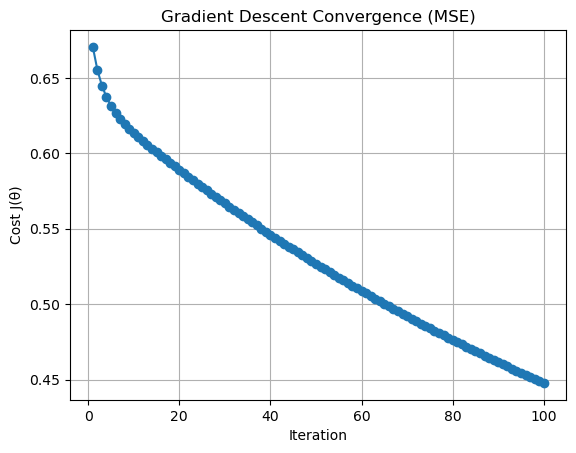

In [17]:
# Reset and track cost history
theta = np.zeros(2)
cost_history = []

for t in range(iterations):
    grad = compute_gradient(X_b, y, theta)
    theta -= eta * grad
    cost_history.append(compute_cost(X_b, y, theta))

plt.plot(range(1, iterations + 1), cost_history, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Cost J(θ)")
plt.title("Gradient Descent Convergence (MSE)")
plt.grid(True)
plt.show()

---
### Gradient Descent Family Demonstration
#### Comparison in NumPy

This example implements and compares the three core flavors of gradient descent for simple linear regression on a small dataset `[(1,1), (2,2), (3,2.5)]`.

#### What it does

A bias term is prepended to the feature matrix (`X_b`), and all three optimizers minimize the **MSE cost function** `J(θ) = 1/2m · Σ(Xθ − y)²` starting from `θ = [0, 0]`.

| Method | Update Rule | Data Used Per Step |
|---|---|---|
| **Batch GD** | Full-dataset gradient per step | All `m` samples |
| **Stochastic GD (SGD)** | One random sample per step | 1 sample |
| **Mini-Batch GD** | Small random subset per step | `batch_size` samples |

#### Key Takeaways

- **Batch GD** converges smoothly but is expensive for large datasets.
- **SGD** updates are noisy but fast — useful for online learning.
- **Mini-Batch GD** balances stability and speed, and is the standard in modern deep learning.

The final plot overlays cost-per-epoch curves for all three, making convergence behavior directly comparable.


Batch GD θ: [0.3307 0.7509]
Stochastic GD θ: [0.3233 0.7256]
Mini-Batch GD θ: [0.3388 0.7525]


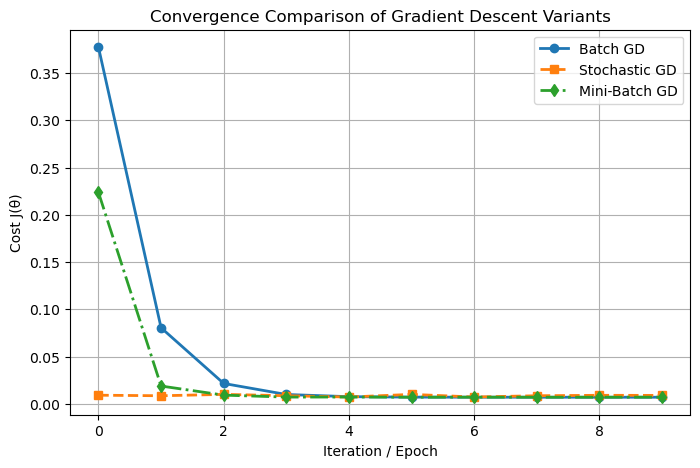

In [19]:
# Dataset: (x, y)
X = np.array([1, 2, 3], dtype=float)
y = np.array([1, 2, 2.5], dtype=float)
m = len(y)

# Add bias term (column of 1s)
X_b = np.c_[np.ones(m), X]  # shape (3, 2)

# Global parameters
eta = 0.1
iterations = 10
np.set_printoptions(precision=4, suppress=True)

def compute_cost(X_b, y, theta):
    """Mean Squared Error cost function."""
    errors = X_b.dot(theta) - y
    return (1 / (2 * len(y))) * np.sum(errors ** 2)

def compute_gradient(X_b, y, theta):
    """Gradient of J(theta)."""
    errors = X_b.dot(theta) - y
    grad = (1 / len(y)) * X_b.T.dot(errors)
    return grad

# 1. Batch Gradient Descent
def batch_gradient_descent(X_b, y, theta_init, eta, iterations):
    theta = theta_init.copy()
    cost_history = []
    for t in range(iterations):
        grad = compute_gradient(X_b, y, theta)
        theta -= eta * grad
        cost_history.append(compute_cost(X_b, y, theta))
    return theta, cost_history

# 2. Stochastic Gradient Descent
def stochastic_gradient_descent(X_b, y, theta_init, eta, epochs):
    theta = theta_init.copy()
    cost_history = []
    for epoch in range(epochs):
        for i in range(len(y)):
            rand_index = np.random.randint(len(y))
            xi = X_b[rand_index:rand_index+1]
            yi = y[rand_index:rand_index+1]
            grad = xi.T.dot(xi.dot(theta) - yi)
            theta -= eta * grad
        cost_history.append(compute_cost(X_b, y, theta))
    return theta, cost_history

# 3. Mini-Batch Gradient Descent
def mini_batch_gradient_descent(X_b, y, theta_init, eta, epochs, batch_size=2):
    theta = theta_init.copy()
    cost_history = []
    for epoch in range(epochs):
        shuffled_indices = np.random.permutation(len(y))
        X_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        for i in range(0, len(y), batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            grad = xi.T.dot(xi.dot(theta) - yi) / batch_size
            theta -= eta * grad
        cost_history.append(compute_cost(X_b, y, theta))
    return theta, cost_history

# Run all methods and compare
theta_init = np.zeros(2)

theta_batch, cost_batch = batch_gradient_descent(X_b, y, theta_init, eta, iterations)
theta_sgd, cost_sgd = stochastic_gradient_descent(X_b, y, theta_init, eta, iterations)
theta_mini, cost_mini = mini_batch_gradient_descent(X_b, y, theta_init, eta, iterations, batch_size=2)

# Print results
print("Batch GD θ:", theta_batch)
print("Stochastic GD θ:", theta_sgd)
print("Mini-Batch GD θ:", theta_mini)

# Visualization
plt.figure(figsize=(8,5))
plt.plot(cost_batch, 'o-', label='Batch GD', linewidth=2)
plt.plot(cost_sgd, 's--', label='Stochastic GD', linewidth=2)
plt.plot(cost_mini, 'd-.', label='Mini-Batch GD', linewidth=2)
plt.xlabel("Iteration / Epoch")
plt.ylabel("Cost J(θ)")
plt.title("Convergence Comparison of Gradient Descent Variants")
plt.legend()
plt.grid(True)
plt.show()


---
## How a Neuron Learns

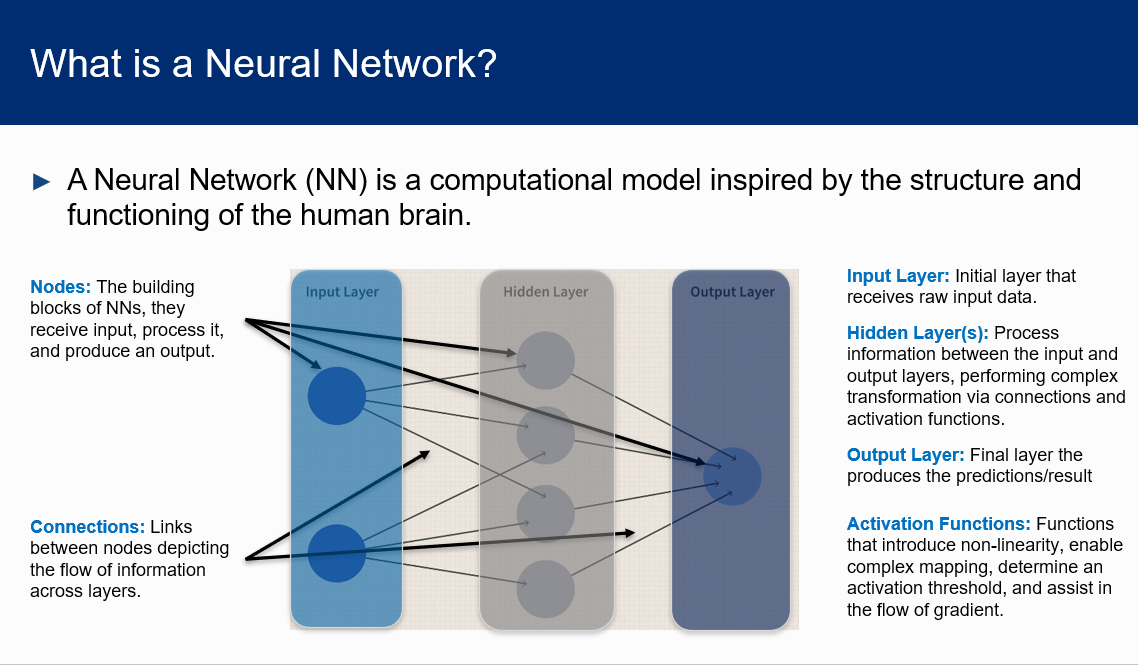

In [5]:
Image('neural_network.png')

### How does a Neural Network Learn?
1. __Initialize__ the Neural Network with random weights/biases.
2. __Forward Pass__ (Inference) data through the input, hidden, and output layers.
3. __Calculate Error__ using error or loss function
4. __Backpropagation__ involving the adjustment of the weights/biases to minimize error, utilizing optimization algorithm.
5. __Repeat__ to convergence.
### How does the individual neuron or node participate in this?

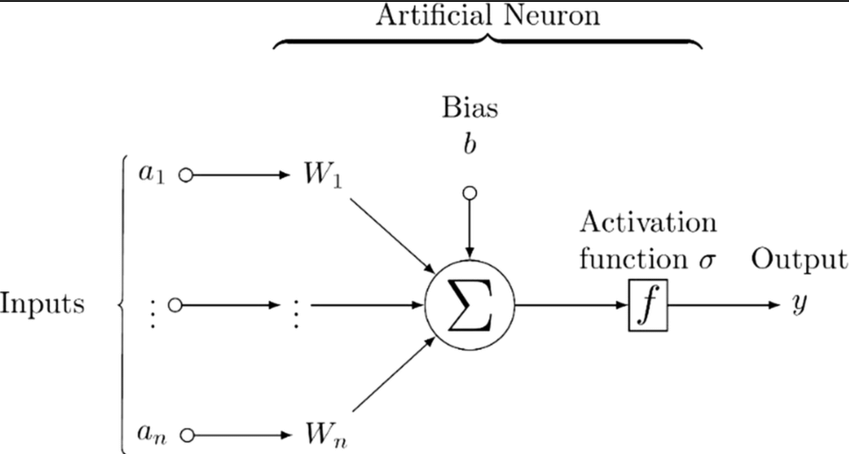

In [6]:
Image('single_artificial_neuron.png')

If we look at this Neuron there are two distinct things happening within each:
1. The summation of the inputs and the weights (addition of bias)
2. An activation function to normalize the value into a particular fashion to be given as inputs to the next layer.

### How does the summation work?

Let's take a look.

If we are going off the above diagram for one neuron then the summation is:

$$a_1 * W_1 + ... + a_n * W_n + b$$

where, $a$ is the input $W$ is the weight and $b$ is the bias. Using the $\sum$ we can then calculate an output after using an activation function, $\sigma$ to normalize the value.

### What do activation functions look like?

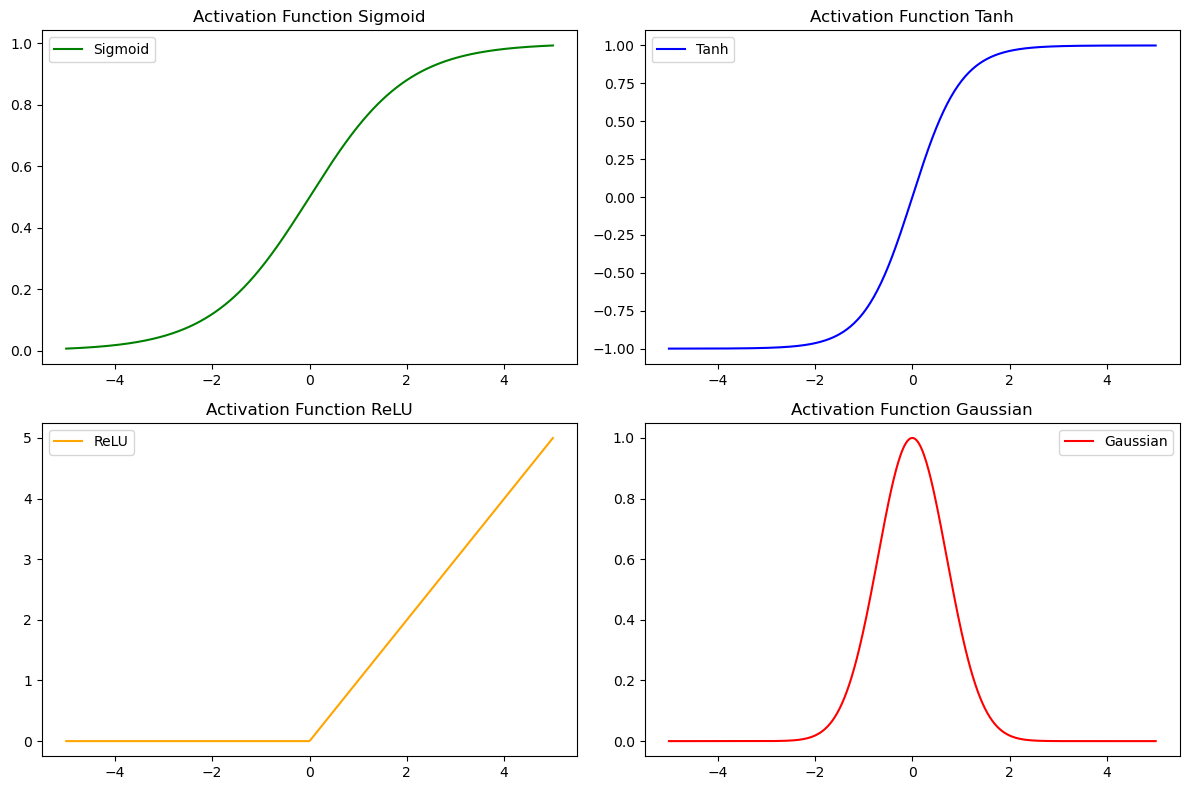

In [7]:
# Define the activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def gaussian(x):
    return np.exp(-x**2)

# Generate x values
x = np.linspace(-5, 5, 400)

# Calculate y values for each activation function
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)
y_gaussian = gaussian(x)

# Create subplots for each activation function
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x, y_sigmoid, label='Sigmoid', color='green')
plt.title('Activation Function Sigmoid')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(x, y_tanh, label='Tanh', color='blue')
plt.title('Activation Function Tanh')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(x, y_relu, label='ReLU', color='orange')
plt.title('Activation Function ReLU')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(x, y_gaussian, label='Gaussian', color='red')
plt.title('Activation Function Gaussian')
plt.legend()

plt.tight_layout()
plt.show()


Each activation function, of which there are many, have different purposes and different ranges that make them preferable for different purposes. 

Once we secure an input and output for each neuron all the way to the output layer we call that the feed forward process. We now have to calculate the error. 

### How do we compute the error?

This will be up to the design of the network but we will show two main one used for regression and classification respectively:

#### Mean Squared Error

$$\frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2$$

#### Binary Cross-Entropy/Log Loss

$$- \frac{1}{n}\sum_{i=1}^{n} (y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1-\hat{y}_i))$$

Now that we have the total error of the system the point now is to distribute the total error back into the system adjusting the weights in order to minimize the loss. The weights are updated in such a way that when the next forward pass utilized the updated weights, the total error of the system is reduced by a certain margin. This happens over and over again until you reach a local minimum, which is the convergence.

### Understanding Backpropagation and the Learning Rate

Now this is where things get interesting — we’ll use the **Chain Rule** from calculus to understand how the **output neuron** (or node) is affected by every layer that comes before it.  

Recall the Chain Rule:

$$
\frac{dy}{dx} = \frac{dy}{du} \times \frac{du}{dx}
$$

This tells us that when a quantity depends on another, which itself depends on something else, we can trace how a small change in the input affects the output by multiplying their individual rates of change.

---

#### Example: A Simple Neural Network

Let’s imagine a small neural network with:

- **Inputs:** $i_1, i_2 $ 
- **Hidden layer:** two neurons $h_1, h_2 $  
- **Outputs:** $ o_1, o_2 $ 
- **Weights:** connections between each layer represented as $ W_n $

We want to see how the **total error** changes with respect to a particular weight $ W_n $. Using the Chain Rule, we write:

$$
\frac{\partial E_{total}}{\partial W_n}
= 
\frac{\partial E_{total}}{\partial output_{o_n}} 
\times 
\frac{\partial output_{o_n}}{\partial sum_{o_n}} 
\times 
\frac{\partial sum_{o_n}}{\partial W_n}
$$

Each term tells us something specific:
- $ \frac{\partial E_{total}}{\partial output_{o_n}} $: How much the total error changes when the output changes  
- $ \frac{\partial output_{o_n}}{\partial sum_{o_n}} $: How the output changes with the weighted sum (depends on the activation function)  
- $ \frac{\partial sum_{o_n}}{\partial W_n} $: How the weighted sum changes when the weight changes  

By multiplying these, we trace how a single weight influences the final error — this is the essence of **backpropagation**.


#### Updating the Weights

Once we compute these gradients for all weights $ W_n $, we can update them to reduce the total error:

$$
W_n^{new} = W_n^{old} - \eta \times \frac{\partial E_{total}}{\partial W_n}
$$

Here, $ \eta $ (Greek letter *eta*) is the **learning rate**.



#### The Role of the Learning Rate

The **learning rate** controls how big a step we take in the direction that reduces error:

- If the learning rate is **too small**, training will be very slow — the weights barely move toward the optimum.  
- If it’s **too large**, the updates may overshoot, causing the model to bounce around and never converge.  

Think of it as adjusting your stride while walking downhill:
- Small steps ensure you don’t trip but take longer to reach the bottom.  
- Huge steps might make you overshoot or fall.  
- A balanced step size helps you descend efficiently.

#### Completing One Backpropagation Cycle

Each time you:
1. Compute the gradients using the Chain Rule  
2. Update the weights using the learning rate  
3. Feed the updated weights back into the network  

you’ve completed **one backpropagation cycle** (or one **training iteration**).  
This process repeats until the network reaches a point of **local convergence**, where further updates no longer reduce the error meaningfully.
